# Two-Stage Model for Solar Panel Area Prediction

This notebook implements a 2-stage prediction pipeline:

**Stage 1 (Classification):** Predict whether a tile has ANY solar panels → `p_solar`

**Stage 2 (Regression):** For tiles predicted to have solar, predict the panel area → `predicted_area`

**Final prediction:** `p_solar × predicted_area`

This approach handles the mixed distribution of our target (many zeros + continuous positive values)
and tests multiple regression models for Stage 2.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
import time
from sklearn.metrics import (r2_score, mean_absolute_error, roc_auc_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

## 1. Load and Prepare Data

In [ ]:
df = pd.read_csv("/home/elsherif/Desktop/Thesis/ViewPython/data/CleanupDataSet/final_model_ev_updated.csv")
df['panel_area_log'] = np.log1p(df['panel_area_m2'])

feature_cols = [
    'year', 'total_rooftops', 'Unemployment_Rate', 'Average_Age',
    'Elderly_Population', 'Young_Population', 'Total_Population',
    'employed', 'pv_price', 'panel_area_lag1', 'ev_points_164m',
    'tile_encoded', 'tile_centroid_lat', 'tile_centroid_lon',
]

# Create binary target
df['has_solar'] = (df['panel_area_m2'] > 0).astype(int)

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['has_solar'].value_counts())
print(f'\nPositive rate: {df["has_solar"].mean()*100:.1f}%')

Dataset shape: (34408, 22)

Class distribution:
has_solar
1    29231
0     5177
Name: count, dtype: int64

Positive rate: 85.0%


## 2. Time-Based Data Split

In [ ]:
# Drop NaN rows (due to lag features)
df_model = df.dropna(subset=feature_cols + ['panel_area_log']).copy()

# Remove extreme outliers
upper_cutoff = df_model[df_model['panel_area_log'] > 0]['panel_area_log'].quantile(0.99)
df_model = df_model[df_model['panel_area_log'] <= upper_cutoff]

# Time-based split
df_model = df_model.sort_values('year')
test_year = df_model['year'].max()
val_year = df_model[df_model['year'] < test_year]['year'].max()

train_df = df_model[df_model['year'] < val_year]
val_df   = df_model[df_model['year'] == val_year]
test_df  = df_model[df_model['year'] == test_year]

print(f'Train: {len(train_df)} (years {sorted(train_df["year"].unique())})')
print(f'Val:   {len(val_df)} (year {val_year})')
print(f'Test:  {len(test_df)} (year {test_year})')
print(f'\nTrain has_solar: {train_df["has_solar"].mean()*100:.1f}%')
print(f'Test  has_solar: {test_df["has_solar"].mean()*100:.1f}%')

Train: 29482 (years [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)])
Val:   1542 (year 2023)
Test:  1539 (year 2024)

Train has_solar: 85.0%
Test  has_solar: 85.6%


## 3. Stage 1: Solar Adoption Classifier (LightGBM)

Predicts the probability that a tile has any solar panels.

In [ ]:
# Stage 1: Train classifier
X_train_1 = train_df[feature_cols]
y_train_1 = train_df['has_solar']
X_val_1   = val_df[feature_cols]
y_val_1   = val_df['has_solar']
X_test_1  = test_df[feature_cols]
y_test_1  = test_df['has_solar']

clf = lgb.LGBMClassifier(
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=32,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
)

clf.fit(
    X_train_1, y_train_1,
    eval_set=[(X_val_1, y_val_1)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=100)],
)

# Predict probabilities
p_solar_test = clf.predict_proba(X_test_1)[:, 1]
y_pred_class = clf.predict(X_test_1)

# Evaluate Stage 1
test_auc = roc_auc_score(y_test_1, p_solar_test)
test_acc = accuracy_score(y_test_1, y_pred_class)
test_f1  = f1_score(y_test_1, y_pred_class)

print(f'\n{"="*60}')
print(f'Stage 1 Results (Classification)')
print(f'{"="*60}')
print(f'ROC-AUC:  {test_auc:.4f}')
print(f'Accuracy: {test_acc:.4f}')
print(f'F1 Score: {test_f1:.4f}')
print(f'\nBest iteration: {clf.best_iteration_}')
print(f'\nClassification Report:')
print(classification_report(y_test_1, y_pred_class, target_names=['No Solar', 'Has Solar']))

Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[179]	valid_0's auc: 0.999309	valid_0's binary_logloss: 0.029563

Stage 1 Results (Classification)
ROC-AUC:  0.9984
Accuracy: 0.9825
F1 Score: 0.9898

Best iteration: 179

Classification Report:
              precision    recall  f1-score   support

    No Solar       0.97      0.91      0.94       222
   Has Solar       0.98      1.00      0.99      1317

    accuracy                           0.98      1539
   macro avg       0.98      0.95      0.96      1539
weighted avg       0.98      0.98      0.98      1539



### Stage 1: Confusion Matrix & SHAP

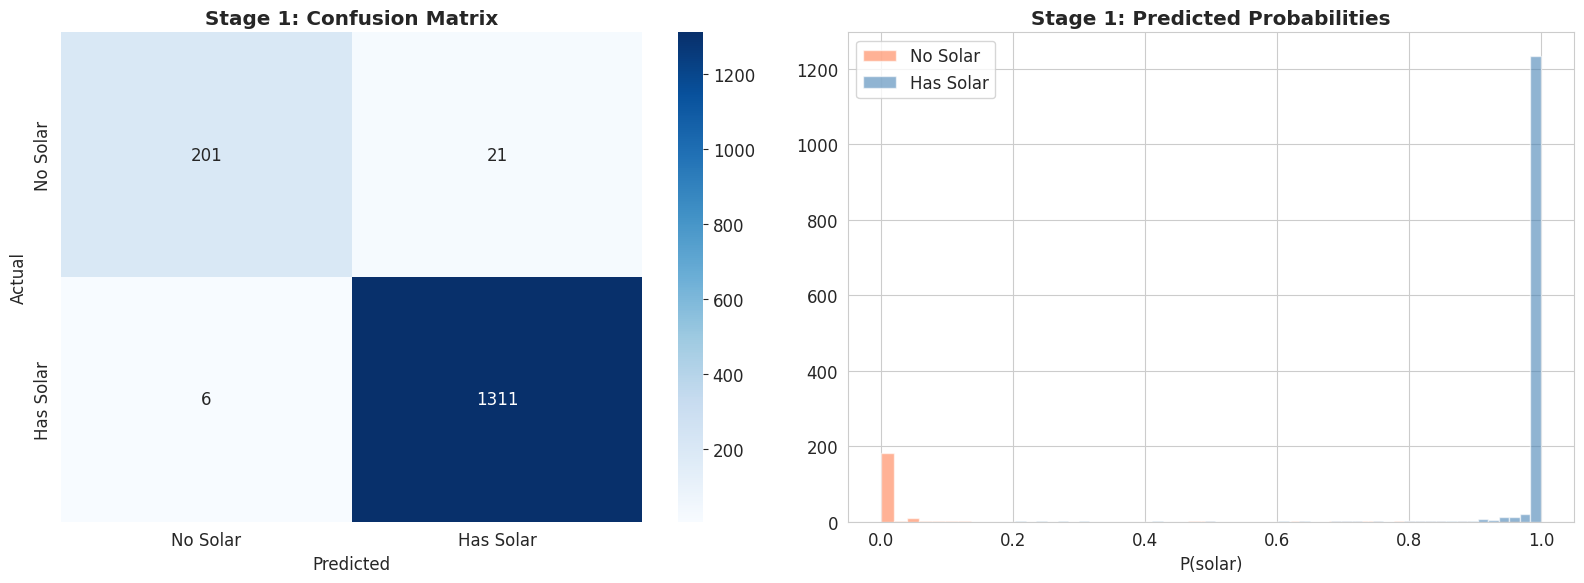

In [ ]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test_1, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Solar', 'Has Solar'],
            yticklabels=['No Solar', 'Has Solar'])
axes[0].set_title('Stage 1: Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Probability distribution
axes[1].hist(p_solar_test[y_test_1 == 0], bins=50, alpha=0.6, label='No Solar', color='coral')
axes[1].hist(p_solar_test[y_test_1 == 1], bins=50, alpha=0.6, label='Has Solar', color='steelblue')
axes[1].set_title('Stage 1: Predicted Probabilities', fontweight='bold')
axes[1].set_xlabel('P(solar)')
axes[1].legend()

plt.tight_layout()
plt.show()

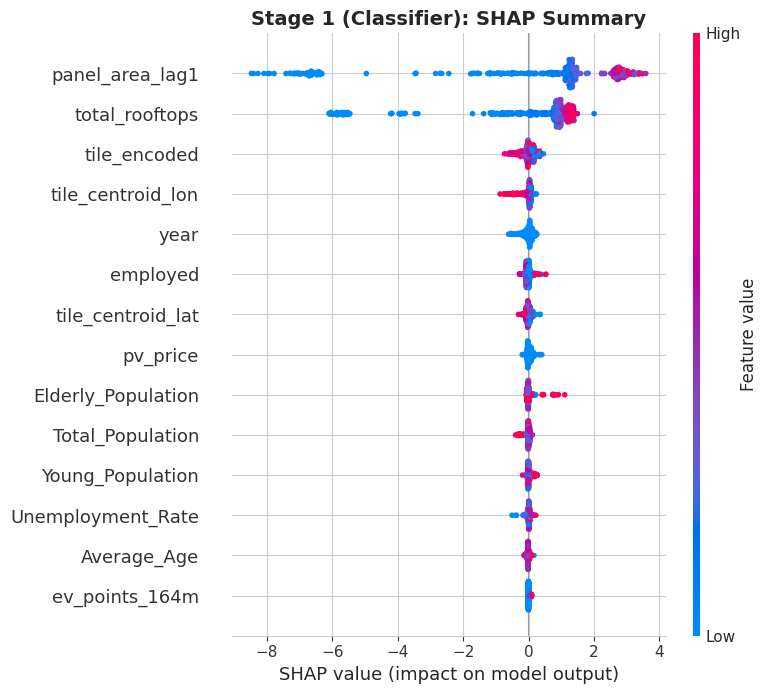

In [ ]:
# SHAP for Stage 1
explainer_s1 = shap.TreeExplainer(clf)
X_shap_s1 = X_test_1.sample(min(500, len(X_test_1)), random_state=42)
shap_values_s1 = explainer_s1(X_shap_s1)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_s1, X_shap_s1, show=False)
plt.title('Stage 1 (Classifier): SHAP Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Stage 2: Panel Area Regression

Train regression models ONLY on positive samples (where solar exists).
We test multiple regressors to find the best Stage 2 model.

In [ ]:
# Stage 2: Train only on positive samples
train_pos = train_df[train_df['has_solar'] == 1]
val_pos   = val_df[val_df['has_solar'] == 1]

X_train_2 = train_pos[feature_cols]
y_train_2 = train_pos['panel_area_log']
X_val_2   = val_pos[feature_cols]
y_val_2   = val_pos['panel_area_log']
X_test_2  = test_df[feature_cols]  # ALL test tiles (we'll combine with p_solar)

print(f'Stage 2 training on {len(train_pos)} positive samples')
print(f'Stage 2 validation on {len(val_pos)} positive samples')

# Define Stage 2 models
stage2_models = {
    'RF': RandomForestRegressor(
        n_estimators=1000, max_depth=None, min_samples_leaf=2,
        min_samples_split=5, max_features='sqrt', random_state=42, n_jobs=-1,
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=1000, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0,
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=1000, max_depth=-1, num_leaves=63,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=10, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
    'HistGBR': HistGradientBoostingRegressor(
        max_iter=1000, max_depth=None, max_leaf_nodes=63,
        learning_rate=0.05, min_samples_leaf=10, l2_regularization=1.0,
        random_state=42,
    ),
}

two_stage_results = {}
stage2_trained = {}

y_test_real = np.expm1(test_df['panel_area_log'].values)

for name, model in stage2_models.items():
    print(f'\n--- Stage 2: {name} ---')
    
    if name == 'XGBoost':
        model.fit(X_train_2, y_train_2, eval_set=[(X_val_2, y_val_2)], verbose=False)
    elif name == 'LightGBM':
        model.fit(X_train_2, y_train_2, eval_set=[(X_val_2, y_val_2)])
    else:
        model.fit(X_train_2, y_train_2)
    
    stage2_trained[name] = model
    
    # Predict panel areas for ALL test tiles
    y_pred_log = model.predict(X_test_2)
    y_pred_size = np.expm1(y_pred_log)
    y_pred_size = np.clip(y_pred_size, 0, None)  # No negative areas
    
    # Combine with Stage 1: final = p_solar * predicted_area
    y_pred_final = p_solar_test * y_pred_size
    
    # Evaluate 2-stage model
    real_r2  = r2_score(y_test_real, y_pred_final)
    real_mae = mean_absolute_error(y_test_real, y_pred_final)
    real_rmse_val = rmse(y_test_real, y_pred_final)
    
    # Also evaluate log-scale
    y_pred_log_final = np.log1p(np.clip(y_pred_final, 0, None))
    log_r2  = r2_score(test_df['panel_area_log'].values, y_pred_log_final)
    log_mae = mean_absolute_error(test_df['panel_area_log'].values, y_pred_log_final)
    
    two_stage_results[name] = {
        'r2_real': real_r2, 'mae_real': real_mae, 'rmse_real': real_rmse_val,
        'r2_log': log_r2, 'mae_log': log_mae,
    }
    
    print(f'  2-Stage R²(real): {real_r2:.4f}  MAE(real): {real_mae:.2f}  RMSE(real): {real_rmse_val:.2f}')
    print(f'  2-Stage R²(log):  {log_r2:.4f}  MAE(log):  {log_mae:.4f}')

Stage 2 training on 25072 positive samples
Stage 2 validation on 1342 positive samples

--- Stage 2: RF ---
  2-Stage R²(real): 0.8426  MAE(real): 83.43  RMSE(real): 173.51
  2-Stage R²(log):  0.9540  MAE(log):  0.2677

--- Stage 2: XGBoost ---
  2-Stage R²(real): 0.9265  MAE(real): 65.42  RMSE(real): 118.55
  2-Stage R²(log):  0.9539  MAE(log):  0.2535

--- Stage 2: LightGBM ---
  2-Stage R²(real): 0.9281  MAE(real): 65.15  RMSE(real): 117.24
  2-Stage R²(log):  0.9533  MAE(log):  0.2558

--- Stage 2: HistGBR ---
  2-Stage R²(real): 0.9431  MAE(real): 57.48  RMSE(real): 104.29
  2-Stage R²(log):  0.9584  MAE(log):  0.2328


## 5. Two-Stage Model Results

Two-Stage Model Comparison (Stage 1: LightGBM Classifier)


,r2_real,mae_real,rmse_real,r2_log,mae_log
RF,0.8426,83.4346,173.5116,0.9540,0.2677
XGBoost,0.9265,65.4211,118.5532,0.9539,0.2535
LightGBM,0.9281,65.1518,117.2412,0.9533,0.2558
HistGBR,0.9431,57.4847,104.2863,0.9584,0.2328


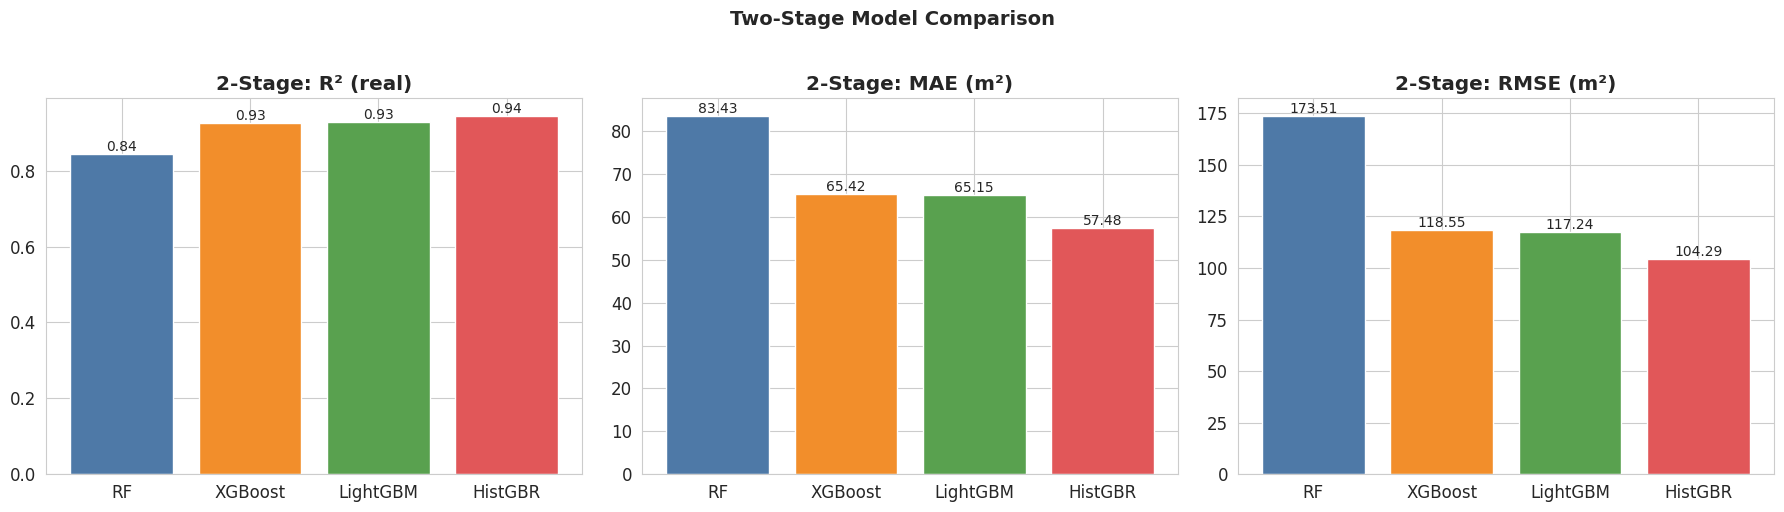

In [ ]:
ts_df = pd.DataFrame(two_stage_results).T.round(4)
print('Two-Stage Model Comparison (Stage 1: LightGBM Classifier)')
display(ts_df)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
names = list(two_stage_results.keys())

for i, (metric, title) in enumerate([('r2_real', 'R² (real)'), 
                                      ('mae_real', 'MAE (m²)'), 
                                      ('rmse_real', 'RMSE (m²)')]):
    vals = [two_stage_results[n][metric] for n in names]
    axes[i].bar(names, vals, color=colors)
    axes[i].set_title(f'2-Stage: {title}', fontweight='bold')
    for j, v in enumerate(vals):
        axes[i].text(j, v, f'{v:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Two-Stage Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. SHAP Analysis for Best Stage 2 Model

In [ ]:
# Find best Stage 2 model by MAE
best_name = min(two_stage_results.keys(), key=lambda k: two_stage_results[k]['mae_real'])
best_model = stage2_trained[best_name]
print(f'Best Stage 2 model: {best_name} (MAE = {two_stage_results[best_name]["mae_real"]:.2f} m²)')

# SHAP analysis
X_shap_s2 = X_test_2.sample(min(500, len(X_test_2)), random_state=42)

if best_name == 'HistGBR':
    explainer_s2 = shap.Explainer(best_model, X_shap_s2)
else:
    explainer_s2 = shap.TreeExplainer(best_model)

shap_values_s2 = explainer_s2(X_shap_s2)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_s2, X_shap_s2, show=False)
plt.title(f'Stage 2 ({best_name}): SHAP Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
shap.plots.bar(shap_values_s2, show=False)
plt.title(f'Stage 2 ({best_name}): Mean |SHAP|', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Best Stage 2 model: HistGBR (MAE = 57.48 m²)


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 4.376473, while the model output was 4.305852. If this difference is acceptable you can set check_additivity=False to disable this check.

## 7. Actual vs Predicted (Two-Stage)

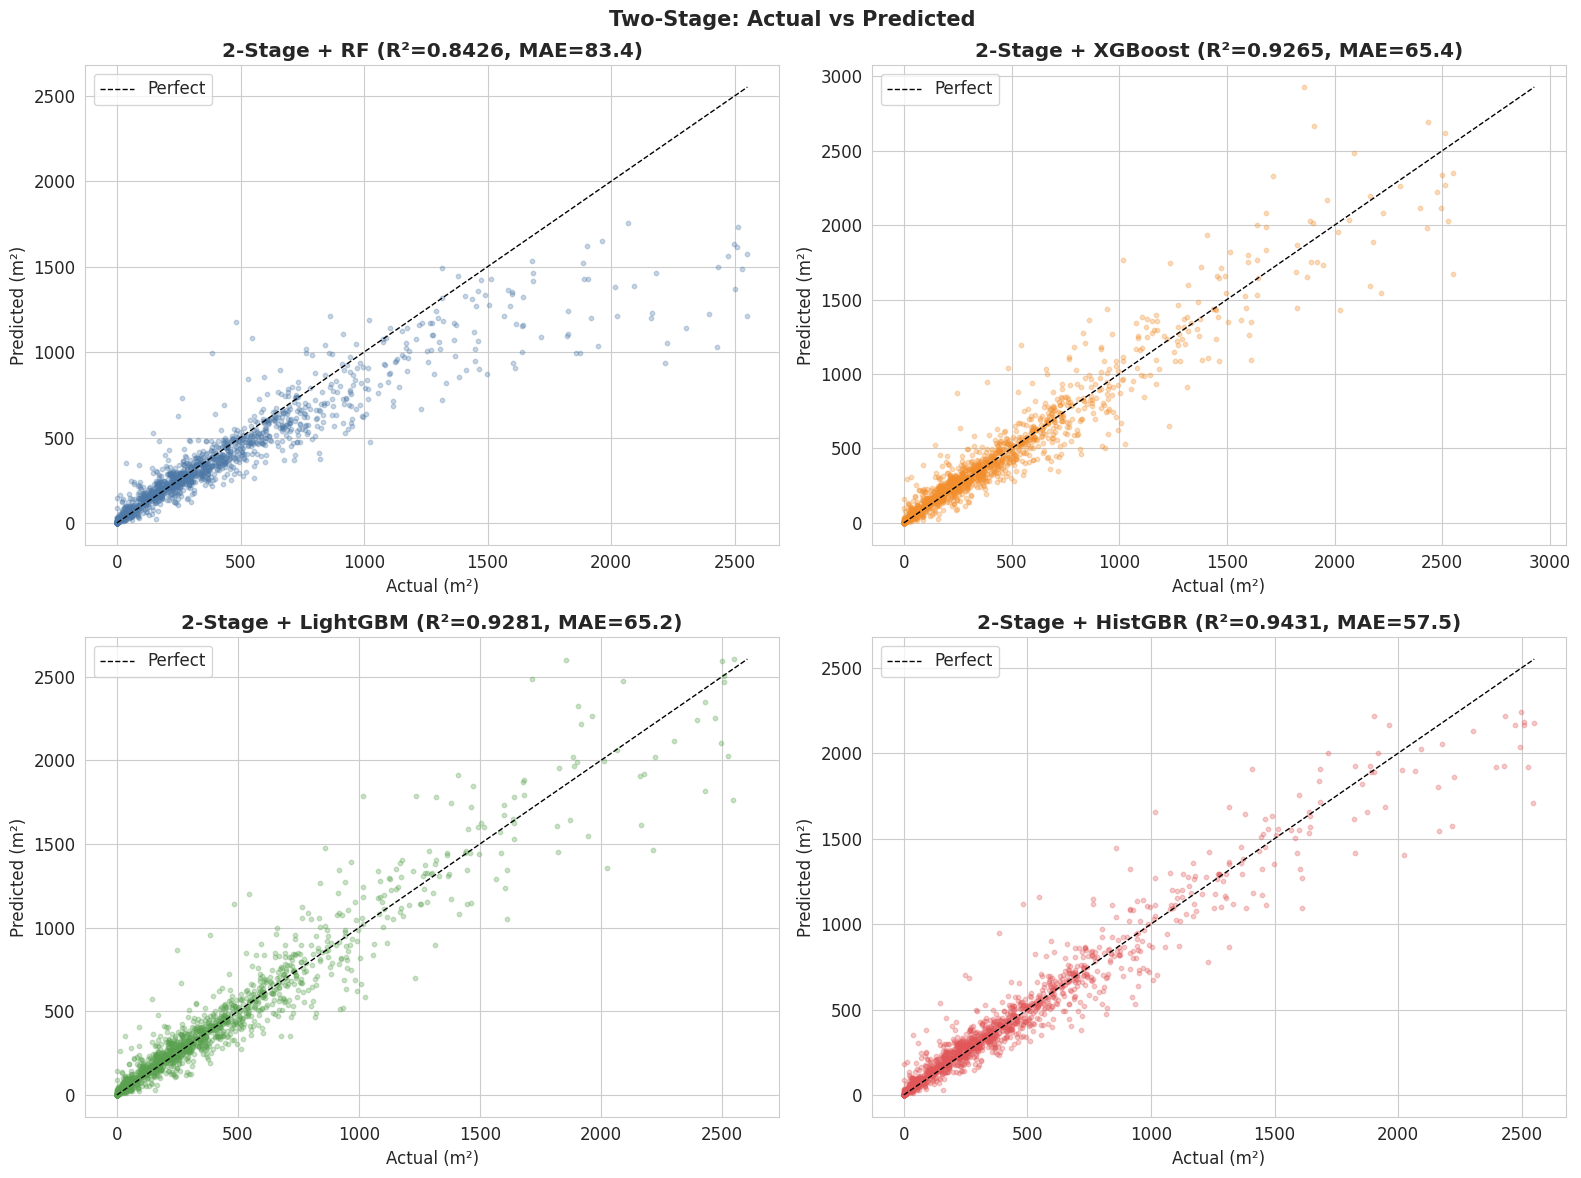

In [ ]:
# Plot actual vs predicted for each Stage 2 model
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (name, model) in enumerate(stage2_trained.items()):
    ax = axes[idx // 2][idx % 2]
    
    y_pred_log = model.predict(X_test_2)
    y_pred_size = np.clip(np.expm1(y_pred_log), 0, None)
    y_pred_final = p_solar_test * y_pred_size
    
    ax.scatter(y_test_real, y_pred_final, alpha=0.3, s=10, color=colors[idx])
    max_val = max(y_test_real.max(), y_pred_final.max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Perfect')
    r2 = two_stage_results[name]['r2_real']
    mae = two_stage_results[name]['mae_real']
    ax.set_title(f'2-Stage + {name} (R²={r2:.4f}, MAE={mae:.1f})', fontweight='bold')
    ax.set_xlabel('Actual (m²)')
    ax.set_ylabel('Predicted (m²)')
    ax.legend()

plt.suptitle('Two-Stage: Actual vs Predicted', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Time-Series Comparison (Best Model)

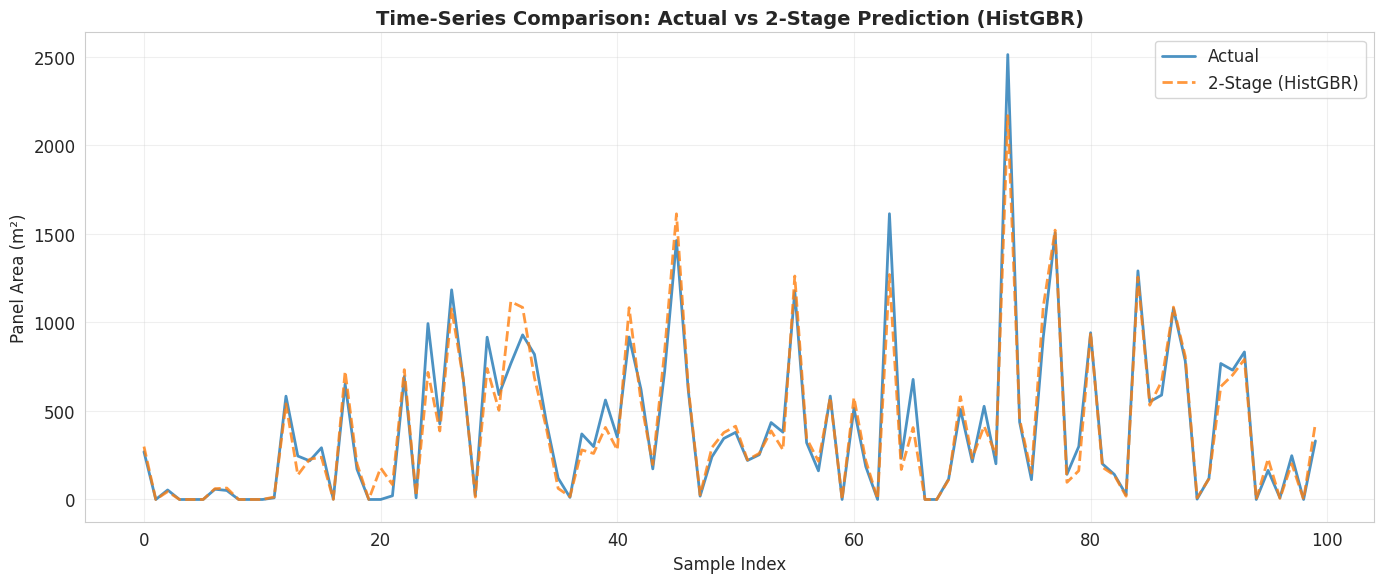

In [ ]:
# Time-series plot for best model
y_pred_log = best_model.predict(X_test_2)
y_pred_size = np.clip(np.expm1(y_pred_log), 0, None)
y_pred_final = p_solar_test * y_pred_size

window = 100
y_true_subset = y_test_real[:window]
y_pred_subset = y_pred_final[:window]
indices = range(len(y_true_subset))

plt.figure(figsize=(14, 6))
plt.plot(indices, y_true_subset, label='Actual', color='#1f77b4', linewidth=2, alpha=0.8)
plt.plot(indices, y_pred_subset, label=f'2-Stage ({best_name})', color='#ff7f0e', linewidth=2, alpha=0.8, linestyle='--')
plt.title(f'Time-Series Comparison: Actual vs 2-Stage Prediction ({best_name})', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Panel Area (m²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Save Best Models

In [ ]:
# Save Stage 1 classifier
clf_path = "/home/elsherif/Desktop/Thesis/ViewPython/Training/stage1_classifier.joblib"
joblib.dump(clf, clf_path)
print(f'Stage 1 classifier saved: {clf_path}')

# Save best Stage 2 regressor
reg_path = f"/home/elsherif/Desktop/Thesis/ViewPython/Training/stage2_{best_name.lower()}.joblib"
joblib.dump(best_model, reg_path)
print(f'Stage 2 regressor saved: {reg_path}')

print(f'\nBest 2-Stage configuration:')
print(f'  Stage 1: LightGBM Classifier (AUC={test_auc:.4f})')
print(f'  Stage 2: {best_name} (MAE={two_stage_results[best_name]["mae_real"]:.2f} m²)')

Stage 1 classifier saved: /home/elsherif/Desktop/Thesis/ViewPython/Training/stage1_classifier.joblib
Stage 2 regressor saved: /home/elsherif/Desktop/Thesis/ViewPython/Training/stage2_histgbr.joblib

Best 2-Stage configuration:
  Stage 1: LightGBM Classifier (AUC=0.9984)
  Stage 2: HistGBR (MAE=57.48 m²)


## 10. Conclusion

### Two-Stage Model Results:
- **Stage 1** (LightGBM Classifier): Very high AUC (~0.997) and accuracy (~97%)
- **Stage 2**: Multiple regressors tested for predicting actual panel area

### Key Insights:
1. The 2-stage approach explicitly models the binary decision (solar or not)
   and the continuous outcome (how much solar) separately
2. This can outperform single-stage models particularly on tiles with no solar
3. The classifier is extremely accurate, so Stage 2 quality is the main differentiator
